Unzip the dataset

In [1]:
import zipfile
import os

with zipfile.ZipFile("northstar_dataset.zip", "r") as z:
    z.extractall()

print(os.listdir("northstar_dataset"))

['vehicles.csv', 'data_dictionary.csv', 'app_events.csv', 'orders.csv', 'drivers.csv', 'README.txt', 'customers.csv', 'deliveries.csv', 'hubs.csv', 'incidents.csv', 'complaints.csv']


Loading the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders     = pd.read_csv("northstar_dataset/orders.csv")
deliveries = pd.read_csv("northstar_dataset/deliveries.csv")
complaints = pd.read_csv("northstar_dataset/complaints.csv")
drivers    = pd.read_csv("northstar_dataset/drivers.csv")
vehicles   = pd.read_csv("northstar_dataset/vehicles.csv")
incidents  = pd.read_csv("northstar_dataset/incidents.csv")

print(deliveries.shape)
print(deliveries.head())

(950, 13)
  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1   

Checking if any missing values

In [3]:
print("Missing values:")
print(deliveries.isnull().sum())

Missing values:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64


Filling in the missing ratings

In [4]:
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median())

NumPy stats

In [5]:
print("Delivery distance stats:")
print("Mean:", np.mean(deliveries['route_distance_km']))
print("Std:", np.std(deliveries['route_distance_km']))
print("Max:", np.max(deliveries['route_distance_km']))

Delivery distance stats:
Mean: 13.909315789473684
Std: 7.473970019182938
Max: 41.94


Delivery Status Bar Chart

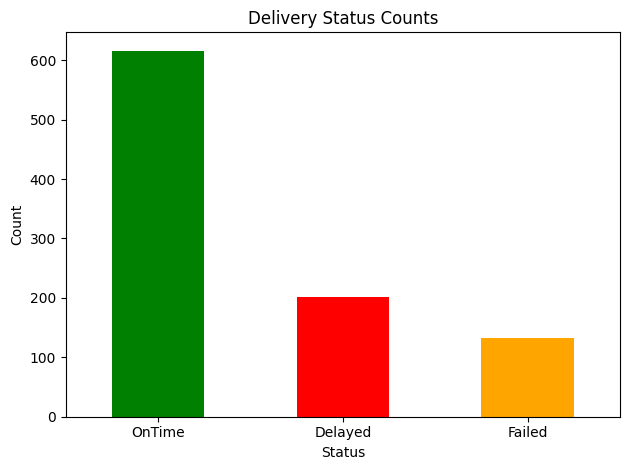

In [6]:
deliveries['delivery_status'].value_counts().plot(kind='bar', color=['green','red','orange'])
plt.title('Delivery Status Counts')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Fuel cost by delivery status

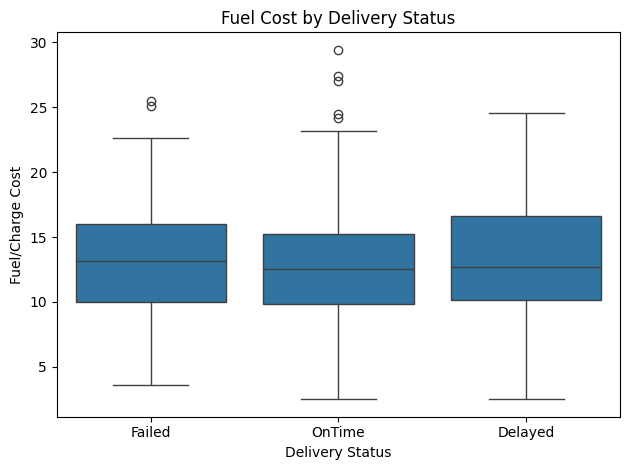

In [7]:
sns.boxplot(data=deliveries, x='delivery_status', y='fuel_or_charge_cost')
plt.title('Fuel Cost by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Fuel/Charge Cost')
plt.tight_layout()
plt.show()

Complaint types

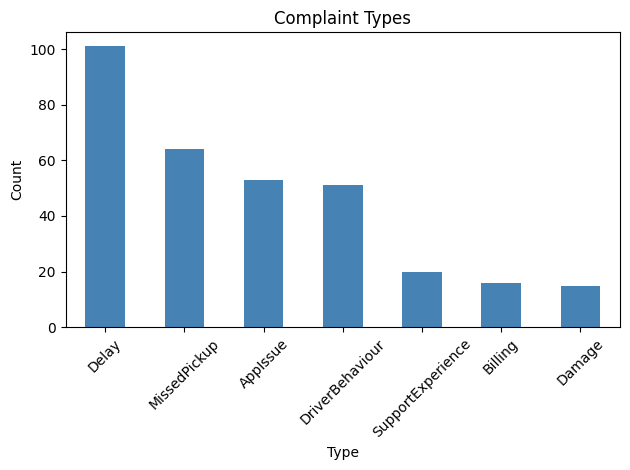

In [8]:
complaints['complaint_type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Complaint Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Correlation heatmap

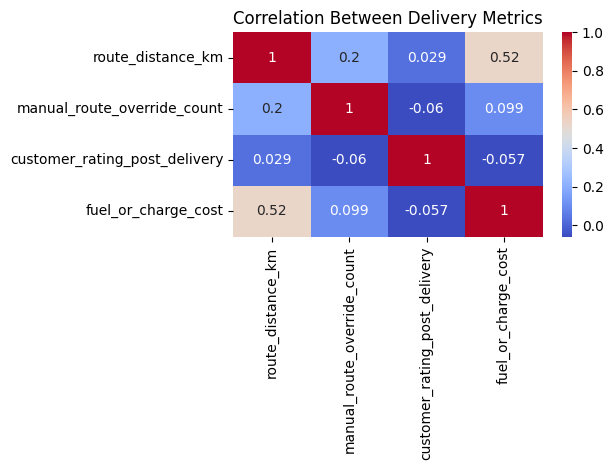

In [9]:
numeric_cols = deliveries[['route_distance_km',
                            'manual_route_override_count',
                            'customer_rating_post_delivery',
                            'fuel_or_charge_cost']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Delivery Metrics')
plt.tight_layout()
plt.show()